PARTÍCULA SOLITÁRIA PROCURANDO O MÍNIMO
Posição inicial: 2.7885
Fitness inicial: 7.7759

Iteração  1: pos =  2.0286, fitness =   4.1150
Iteração  2: pos =  1.4206, fitness =   2.0180
Iteração  3: pos =  0.9342, fitness =   0.8727
Iteração  4: pos =  0.5451, fitness =   0.2971
Iteração  5: pos =  0.2338, fitness =   0.0547
Iteração  6: pos = -0.0153, fitness =   0.0002
Iteração  7: pos = -0.2145, fitness =   0.0460
Iteração  8: pos = -0.1319, fitness =   0.0174
Iteração  9: pos =  0.0769, fitness =   0.0059
Iteração 10: pos =  0.0360, fitness =   0.0013
Iteração 11: pos = -0.0348, fitness =   0.0012
Iteração 12: pos = -0.0535, fitness =   0.0029
Iteração 13: pos = -0.0576, fitness =   0.0033
Iteração 14: pos =  0.0313, fitness =   0.0010
Iteração 15: pos = -0.0049, fitness =   0.0000
Iteração 16: pos = -0.0339, fitness =   0.0011
Iteração 17: pos = -0.0166, fitness =   0.0003
Iteração 18: pos =  0.0226, fitness =   0.0005
Iteração 19: pos = -0.0054, fitness =   0.0000
Iteração 20: pos =

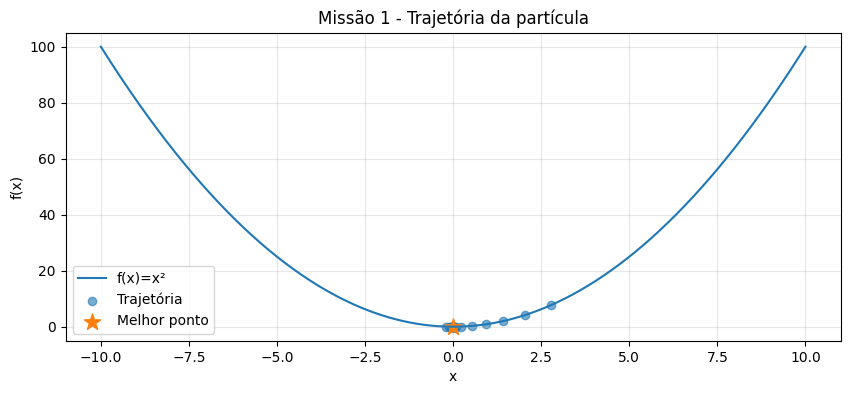

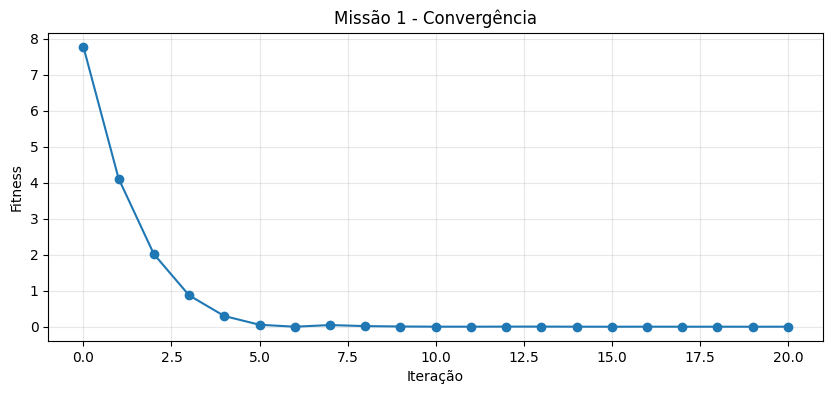

In [1]:
"""
MISSÃO 1: A PARTÍCULA SOLITÁRIA
Cenário: Uma partícula procurando o mínimo de f(x) = x²
Domínio: x ∈ [-10, 10]
"""
import numpy as np
import matplotlib.pyplot as plt
import random

random.seed(42)
np.random.seed(42)

ITERACOES = 20
W = 0.8
C1 = 1.5
C2 = 1.5
LIMITE = 10

def funcao(x):
    return x**2

posicao = random.uniform(-LIMITE, LIMITE)
velocidade = random.uniform(-1, 1)
fitness = funcao(posicao)

pBest_pos = posicao
pBest_fit = fitness
gBest_pos = posicao
gBest_fit = fitness

historico_pos = [posicao]
historico_fit = [fitness]

print("=" * 60)
print("PARTÍCULA SOLITÁRIA PROCURANDO O MÍNIMO")
print("=" * 60)
print(f"Posição inicial: {posicao:.4f}")
print(f"Fitness inicial: {fitness:.4f}\n")

for i in range(ITERACOES):
    r1 = random.random()
    r2 = random.random()

    # TODO 1 resolvido: atualização da velocidade
    velocidade_nova = (
        W * velocidade
        + C1 * r1 * (pBest_pos - posicao)
        + C2 * r2 * (gBest_pos - posicao)
    )

    # TODO 2 resolvido: atualização da posição
    posicao_nova = posicao + velocidade_nova
    posicao_nova = np.clip(posicao_nova, -LIMITE, LIMITE)

    fitness_novo = funcao(posicao_nova)

    posicao = float(posicao_nova)
    velocidade = float(velocidade_nova)
    fitness = float(fitness_novo)

    if fitness < pBest_fit:
        pBest_fit = fitness
        pBest_pos = posicao

    if fitness < gBest_fit:
        gBest_fit = fitness
        gBest_pos = posicao

    historico_pos.append(posicao)
    historico_fit.append(fitness)

    print(f"Iteração {i+1:2d}: pos = {posicao:7.4f}, fitness = {fitness:8.4f}")

print("\n" + "=" * 60)
print("RESULTADO FINAL")
print("=" * 60)
print(f"Posição final: {posicao:.6f}")
print(f"Fitness final: {fitness:.6f}")
print(f"Melhor posição encontrada: {gBest_pos:.6f}")
print(f"Melhor fitness encontrado: {gBest_fit:.6f}")
print("Ótimo global: x = 0.000000, f(x) = 0.000000")

x_plot = np.linspace(-LIMITE, LIMITE, 1000)
y_plot = funcao(x_plot)

plt.figure(figsize=(10, 4))
plt.plot(x_plot, y_plot, label='f(x)=x²')
plt.scatter(historico_pos, [funcao(p) for p in historico_pos], alpha=0.6, label='Trajetória')
plt.scatter(gBest_pos, gBest_fit, s=150, marker='*', label='Melhor ponto')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Missão 1 - Trajetória da partícula')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(range(ITERACOES + 1), historico_fit, marker='o')
plt.xlabel('Iteração')
plt.ylabel('Fitness')
plt.title('Missão 1 - Convergência')
plt.grid(alpha=0.3)
plt.show()


PSO - FUNÇÃO DE ROSENBROCK
Início: Melhor fitness = 3.363231
Iteração  10: Melhor = 0.213414
Iteração  20: Melhor = 0.182157
Iteração  30: Melhor = 0.000468
Iteração  40: Melhor = 0.000468
Iteração  50: Melhor = 0.000348

Fim: posição = (1.011065, 1.020752)
Melhor fitness = 0.000348
Ótimo global esperado: (1, 1), fitness = 0


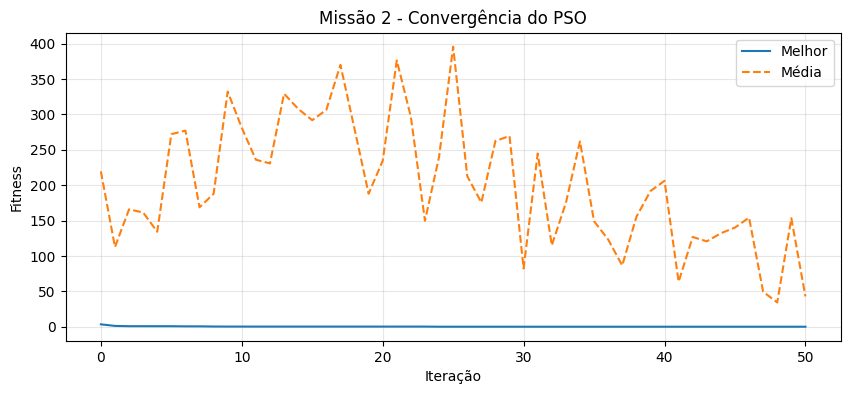

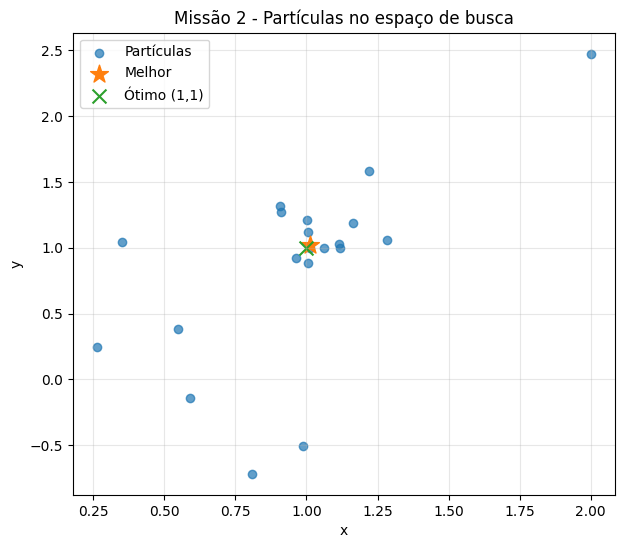

In [2]:
"""
MISSÃO 2: O ENXAME DE PARTÍCULAS
Função de Rosenbrock:
f(x,y) = (1-x)² + 100*(y-x²)²
"""
import numpy as np
import matplotlib.pyplot as plt
import random

np.random.seed(42)
random.seed(42)

NUM_PARTICULAS = 20
ITERACOES = 50
W = 0.7
C1 = 1.8
C2 = 1.8
X_MIN, X_MAX = -2, 2
Y_MIN, Y_MAX = -1, 3

def rosenbrock(posicao):
    x, y = posicao
    return (1 - x)**2 + 100 * (y - x**2)**2

def criar_particula():
    posicao = np.array([
        np.random.uniform(X_MIN, X_MAX),
        np.random.uniform(Y_MIN, Y_MAX)
    ])
    velocidade = np.random.uniform(-0.5, 0.5, 2)
    fit = rosenbrock(posicao)

    return {
        'posicao': posicao,
        'velocidade': velocidade,
        'fitness': fit,
        'pBest_pos': posicao.copy(),
        'pBest_fit': fit
    }

def atualizar_velocidade(particula, gBest_pos):
    r1 = np.random.random(2)
    r2 = np.random.random(2)

    return (
        W * particula['velocidade']
        + C1 * r1 * (particula['pBest_pos'] - particula['posicao'])
        + C2 * r2 * (gBest_pos - particula['posicao'])
    )

def atualizar_posicao(particula):
    nova_posicao = particula['posicao'] + particula['velocidade']
    nova_posicao[0] = np.clip(nova_posicao[0], X_MIN, X_MAX)
    nova_posicao[1] = np.clip(nova_posicao[1], Y_MIN, Y_MAX)
    return nova_posicao

def executar_pso():
    enxame = [criar_particula() for _ in range(NUM_PARTICULAS)]

    melhor = min(enxame, key=lambda p: p['fitness'])
    gBest_pos = melhor['posicao'].copy()
    gBest_fit = melhor['fitness']

    historico = {
        'melhor': [gBest_fit],
        'media': [np.mean([p['fitness'] for p in enxame])]
    }

    print("=" * 60)
    print("PSO - FUNÇÃO DE ROSENBROCK")
    print("=" * 60)
    print(f"Início: Melhor fitness = {gBest_fit:.6f}")

    for iteracao in range(ITERACOES):
        for p in enxame:
            p['velocidade'] = atualizar_velocidade(p, gBest_pos)
            p['posicao'] = atualizar_posicao(p)
            p['fitness'] = rosenbrock(p['posicao'])

            if p['fitness'] < p['pBest_fit']:
                p['pBest_fit'] = p['fitness']
                p['pBest_pos'] = p['posicao'].copy()

            if p['fitness'] < gBest_fit:
                gBest_fit = p['fitness']
                gBest_pos = p['posicao'].copy()

        historico['melhor'].append(gBest_fit)
        historico['media'].append(np.mean([p['fitness'] for p in enxame]))

        if (iteracao + 1) % 10 == 0:
            print(f"Iteração {iteracao+1:3d}: Melhor = {gBest_fit:.6f}")

    print(f"\nFim: posição = ({gBest_pos[0]:.6f}, {gBest_pos[1]:.6f})")
    print(f"Melhor fitness = {gBest_fit:.6f}")
    print("Ótimo global esperado: (1, 1), fitness = 0")

    return gBest_pos, gBest_fit, historico, enxame

best_pos_m2, best_fit_m2, historico_m2, enxame_m2 = executar_pso()

plt.figure(figsize=(10, 4))
plt.plot(historico_m2['melhor'], label='Melhor')
plt.plot(historico_m2['media'], linestyle='--', label='Média')
plt.xlabel('Iteração')
plt.ylabel('Fitness')
plt.title('Missão 2 - Convergência do PSO')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

x_pos = [p['posicao'][0] for p in enxame_m2]
y_pos = [p['posicao'][1] for p in enxame_m2]
plt.figure(figsize=(7, 6))
plt.scatter(x_pos, y_pos, alpha=0.7, label='Partículas')
plt.scatter(best_pos_m2[0], best_pos_m2[1], s=180, marker='*', label='Melhor')
plt.scatter(1, 1, s=100, marker='x', label='Ótimo (1,1)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Missão 2 - Partículas no espaço de busca')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


OTIMIZAÇÃO LOGÍSTICA COM PSO
Melhor custo inicial: 4394.94

Iteração  20: custo = 3716.12
Iteração  40: custo = 3581.58
Iteração  60: custo = 3526.28
Iteração  80: custo = 3517.56
Iteração 100: custo = 3514.93

RESULTADO FINAL
Tempo de execução: 1.5062 segundos
Custo inicial: 4394.94
Custo final: 3514.93
Melhoria: 880.01
Centros de distribuição:
Centro 1: (2.70, 5.32)
Centro 2: (0.59, 8.65)
Centro 3: (5.47, 1.76)
Centro 4: (0.90, 1.94)
Centro 5: (7.74, 6.12)


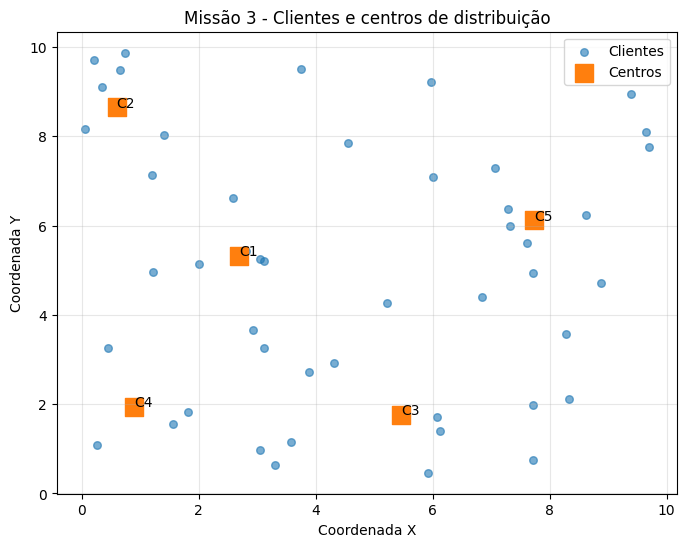

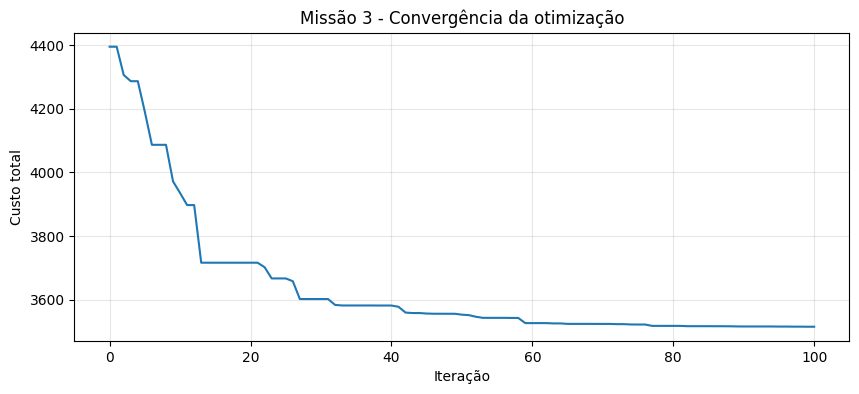

In [3]:
"""
MISSÃO 3: OTIMIZAÇÃO LOGÍSTICA
Encontrar a localização de 5 centros de distribuição
que minimize o custo de entrega para 50 clientes.
"""
import numpy as np
import matplotlib.pyplot as plt
import random
import time

np.random.seed(42)
random.seed(42)

NUM_CLIENTES = 50
NUM_CENTROS = 5
NUM_PARTICULAS = 30
ITERACOES = 100
W = 0.7
C1 = 1.8
C2 = 1.8
LIMITE = 10

# Dados do problema
np.random.seed(42)
clientes = np.random.rand(NUM_CLIENTES, 2) * LIMITE
demandas = np.random.randint(1, 100, NUM_CLIENTES)

def fitness(posicoes_centros):
    # TODO 1: converter as 10 dimensões em 5 pares (x,y)
    centros = np.array(posicoes_centros).reshape(NUM_CENTROS, 2)

    custo_total = 0.0

    for cliente, demanda in zip(clientes, demandas):
        # TODO 2 e 3: calcular as distâncias e pegar o centro mais próximo
        distancias = np.linalg.norm(centros - cliente, axis=1)
        distancia_minima = np.min(distancias)

        # TODO 4: custo = distância x demanda
        custo_total += distancia_minima * demanda

    # Como o problema é de minimização, retornamos o custo positivo.
    return custo_total

def criar_particula():
    dim = NUM_CENTROS * 2
    posicao = np.random.uniform(0, LIMITE, dim)
    velocidade = np.random.uniform(-0.5, 0.5, dim)
    fit = fitness(posicao)

    return {
        'posicao': posicao,
        'velocidade': velocidade,
        'fitness': fit,
        'pBest_pos': posicao.copy(),
        'pBest_fit': fit
    }

def atualizar_velocidade(particula, gBest_pos):
    dim = NUM_CENTROS * 2
    r1 = np.random.random(dim)
    r2 = np.random.random(dim)

    return (
        W * particula['velocidade']
        + C1 * r1 * (particula['pBest_pos'] - particula['posicao'])
        + C2 * r2 * (gBest_pos - particula['posicao'])
    )

def atualizar_posicao(particula):
    nova_posicao = particula['posicao'] + particula['velocidade']
    return np.clip(nova_posicao, 0, LIMITE)

def executar_pso():
    enxame = [criar_particula() for _ in range(NUM_PARTICULAS)]

    melhor = min(enxame, key=lambda p: p['fitness'])
    gBest_pos = melhor['posicao'].copy()
    gBest_fit = melhor['fitness']
    custo_inicial = gBest_fit

    historico = [gBest_fit]

    print("=" * 60)
    print("OTIMIZAÇÃO LOGÍSTICA COM PSO")
    print("=" * 60)
    print(f"Melhor custo inicial: {custo_inicial:.2f}\n")

    inicio = time.perf_counter()

    for iteracao in range(ITERACOES):
        for p in enxame:
            p['velocidade'] = atualizar_velocidade(p, gBest_pos)
            p['posicao'] = atualizar_posicao(p)
            p['fitness'] = fitness(p['posicao'])

            if p['fitness'] < p['pBest_fit']:
                p['pBest_fit'] = p['fitness']
                p['pBest_pos'] = p['posicao'].copy()

            if p['fitness'] < gBest_fit:
                gBest_fit = p['fitness']
                gBest_pos = p['posicao'].copy()

        historico.append(gBest_fit)

        if (iteracao + 1) % 20 == 0:
            print(f"Iteração {iteracao+1:3d}: custo = {gBest_fit:.2f}")

    tempo = time.perf_counter() - inicio
    return gBest_pos, gBest_fit, historico, tempo, custo_inicial

best_pos_m3, best_fit_m3, historico_m3, exec_time_m3, custo_inicial_m3 = executar_pso()
centros_m3 = best_pos_m3.reshape(NUM_CENTROS, 2)

print("\nRESULTADO FINAL")
print(f"Tempo de execução: {exec_time_m3:.4f} segundos")
print(f"Custo inicial: {custo_inicial_m3:.2f}")
print(f"Custo final: {best_fit_m3:.2f}")
print(f"Melhoria: {custo_inicial_m3 - best_fit_m3:.2f}")
print("Centros de distribuição:")
for i, centro in enumerate(centros_m3, start=1):
    print(f"Centro {i}: ({centro[0]:.2f}, {centro[1]:.2f})")

plt.figure(figsize=(8, 6))
plt.scatter(clientes[:, 0], clientes[:, 1], s=30, alpha=0.6, label='Clientes')
plt.scatter(centros_m3[:, 0], centros_m3[:, 1], s=180, marker='s', label='Centros')
for i, centro in enumerate(centros_m3, start=1):
    plt.annotate(f'C{i}', (centro[0], centro[1]))
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.title('Missão 3 - Clientes e centros de distribuição')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(historico_m3)
plt.xlabel('Iteração')
plt.ylabel('Custo total')
plt.title('Missão 3 - Convergência da otimização')
plt.grid(alpha=0.3)
plt.show()


EXPERIMENTOS COM PARÂMETROS DO PSO
Padrão             | média = 3596.33 ± 61.49
Inércia Alta       | média = 3998.92 ± 126.16
Inércia Baixa      | média = 3678.37 ± 138.84
Cognitivo Alto     | média = 3791.46 ± 141.91
Social Alto        | média = 4012.52 ± 110.87
Mais Partículas    | média = 3636.36 ± 95.02

| Experimento | Custo Médio | Melhor Custo | Pior Custo |
|---|---:|---:|---:|
| Padrão | 3596.33 | 3543.98 | 3703.59 |
| Inércia Alta | 3998.92 | 3856.11 | 4163.21 |
| Inércia Baixa | 3678.37 | 3513.98 | 3930.22 |
| Cognitivo Alto | 3791.46 | 3598.17 | 4011.01 |
| Social Alto | 4012.52 | 3884.98 | 4179.25 |
| Mais Partículas | 3636.36 | 3537.39 | 3801.62 |

ANÁLISE E CONCLUSÕES
1. Melhor configuração pelo custo médio: Padrão
2. Pior configuração pelo custo médio: Social Alto

3. Efeitos observados:
- Inércia alta manteve mais exploração, mas convergiu pior neste teste.
- Inércia baixa favoreceu convergência mais estável.
- c1 alto reforçou a experiência individual, mas não foi o m

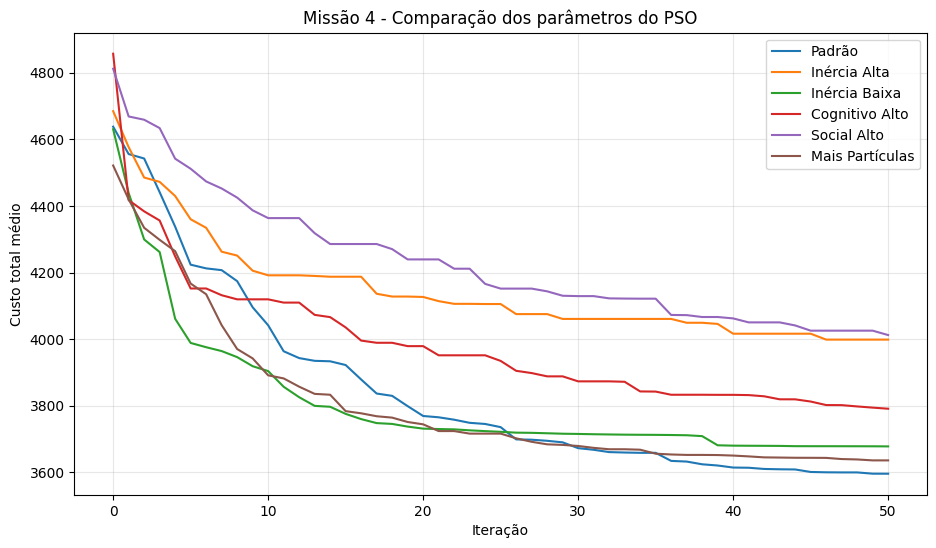

In [4]:
"""
MISSÃO 4: OTIMIZAÇÃO DOS PARÂMETROS DO PSO
"""
import numpy as np
import matplotlib.pyplot as plt
import random

BASE_PARAMS = {
    'num_particulas': 30,
    'iteracoes': 50,
    'w': 0.7,
    'c1': 1.8,
    'c2': 1.8,
    'limite': 10,
    'num_centros': 5,
    'num_clientes': 50
}

EXPERIMENTOS = [
    {'nome': 'Padrão', 'params': BASE_PARAMS.copy()},
    {'nome': 'Inércia Alta', 'params': {**BASE_PARAMS, 'w': 0.9}},
    {'nome': 'Inércia Baixa', 'params': {**BASE_PARAMS, 'w': 0.5}},
    {'nome': 'Cognitivo Alto', 'params': {**BASE_PARAMS, 'c1': 2.5}},
    {'nome': 'Social Alto', 'params': {**BASE_PARAMS, 'c2': 2.5}},
    {'nome': 'Mais Partículas', 'params': {**BASE_PARAMS, 'num_particulas': 60}},
]

np.random.seed(42)
random.seed(42)
clientes = np.random.rand(BASE_PARAMS['num_clientes'], 2) * BASE_PARAMS['limite']
demandas = np.random.randint(1, 100, BASE_PARAMS['num_clientes'])

def fitness_parametros(posicoes_centros, clientes, demandas, num_centros):
    centros = np.array(posicoes_centros).reshape(num_centros, 2)
    custo_total = 0.0

    for cliente, demanda in zip(clientes, demandas):
        distancias = np.linalg.norm(centros - cliente, axis=1)
        custo_total += np.min(distancias) * demanda

    return custo_total

def executar_pso_parametros(params, clientes, demandas):
    num_particulas = params['num_particulas']
    iteracoes = params['iteracoes']
    w = params['w']
    c1 = params['c1']
    c2 = params['c2']
    limite = params['limite']
    num_centros = params['num_centros']
    dim = num_centros * 2

    enxame = []

    for _ in range(num_particulas):
        posicao = np.random.uniform(0, limite, dim)
        velocidade = np.random.uniform(-0.5, 0.5, dim)
        fit = fitness_parametros(posicao, clientes, demandas, num_centros)

        enxame.append({
            'posicao': posicao,
            'velocidade': velocidade,
            'fitness': fit,
            'pBest_pos': posicao.copy(),
            'pBest_fit': fit
        })

    melhor = min(enxame, key=lambda p: p['fitness'])
    gBest_pos = melhor['posicao'].copy()
    gBest_fit = melhor['fitness']

    historico = [gBest_fit]

    for _ in range(iteracoes):
        for p in enxame:
            r1 = np.random.random(dim)
            r2 = np.random.random(dim)

            p['velocidade'] = (
                w * p['velocidade']
                + c1 * r1 * (p['pBest_pos'] - p['posicao'])
                + c2 * r2 * (gBest_pos - p['posicao'])
            )

            p['posicao'] = np.clip(
                p['posicao'] + p['velocidade'], 0, limite
            )

            p['fitness'] = fitness_parametros(
                p['posicao'], clientes, demandas, num_centros
            )

            if p['fitness'] < p['pBest_fit']:
                p['pBest_fit'] = p['fitness']
                p['pBest_pos'] = p['posicao'].copy()

            if p['fitness'] < gBest_fit:
                gBest_fit = p['fitness']
                gBest_pos = p['posicao'].copy()

        historico.append(gBest_fit)

    return gBest_fit, historico

np.random.seed(42)
random.seed(42)

resultados = {}

print("=" * 68)
print("EXPERIMENTOS COM PARÂMETROS DO PSO")
print("=" * 68)

for exp in EXPERIMENTOS:
    custos = []
    historicos = []

    for _ in range(5):
        custo_final, historico = executar_pso_parametros(
            exp['params'], clientes, demandas
        )
        custos.append(custo_final)
        historicos.append(historico)

    resultados[exp['nome']] = {
        'custo_medio': np.mean(custos),
        'custo_std': np.std(custos),
        'melhor_custo': np.min(custos),
        'pior_custo': np.max(custos),
        'historico': np.mean(historicos, axis=0),
        'params': exp['params']
    }

    print(
        f"{exp['nome']:<18} | "
        f"média = {resultados[exp['nome']]['custo_medio']:.2f} ± "
        f"{resultados[exp['nome']]['custo_std']:.2f}"
    )

print("\n| Experimento | Custo Médio | Melhor Custo | Pior Custo |")
print("|---|---:|---:|---:|")
for nome, data in resultados.items():
    print(
        f"| {nome} | {data['custo_medio']:.2f} | "
        f"{data['melhor_custo']:.2f} | {data['pior_custo']:.2f} |"
    )

melhor_nome, melhor_data = min(
    resultados.items(), key=lambda x: x[1]['custo_medio']
)
pior_nome, pior_data = max(
    resultados.items(), key=lambda x: x[1]['custo_medio']
)

print("\nANÁLISE E CONCLUSÕES")
print("1. Melhor configuração pelo custo médio:", melhor_nome)
print("2. Pior configuração pelo custo médio:", pior_nome)
print("\n3. Efeitos observados:")
print("- Inércia alta manteve mais exploração, mas convergiu pior neste teste.")
print("- Inércia baixa favoreceu convergência mais estável.")
print("- c1 alto reforçou a experiência individual, mas não foi o melhor.")
print("- c2 alto fez o enxame seguir muito o gBest e reduziu diversidade.")
print("- Mais partículas aumentaram a exploração, porém também o custo computacional.")
print("\n4. Recomendação:")
print(f"Usar '{melhor_nome}' entre as configurações testadas, pois apresentou o menor custo médio.")

plt.figure(figsize=(11, 6))
for nome, data in resultados.items():
    plt.plot(data['historico'], label=nome)
plt.xlabel('Iteração')
plt.ylabel('Custo total médio')
plt.title('Missão 4 - Comparação dos parâmetros do PSO')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
